In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from src.evaluation import check_release_targets, collect_predictions, load_test_dataset, per_class_report, plot_confusion_matrix

I0000 00:00:1789326508.148994    1170 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789326509.276163    1170 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
MODEL_PATH = "cat_dog_mobilenetv3.keras"
TEST_DIR = "content/cats-and-dogs-for-classification/cats_dogs/test"
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
PREVIOUS = None

In [3]:
model = keras.saving.load_model(MODEL_PATH)
test_data, class_names = load_test_dataset(TEST_DIR, IMAGE_SIZE, BATCH_SIZE)
class_names

W0000 00:00:1789326518.099996    1170 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789326518.102638    1170 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789326518.182649    1170 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


Found 2000 files belonging to 2 classes.


['cats', 'dogs']

In [4]:
y_true, y_prob = collect_predictions(model, test_data)
report = per_class_report(y_true, y_prob, class_names)
report["class_counts"]

{'cats': 1000, 'dogs': 1000}

In [5]:
per_class = pd.DataFrame(report["classes"]).set_index("class")
per_class["recall %"] = (per_class["recall"] * 100).round(2)
per_class["95% range ±"] = (per_class["recall_interval"] * 100).round(2)
per_class[["support", "correct", "recall %", "95% range ±", "precision", "f1"]].round(4)

,support,correct,recall %,95% range ±,precision,f1
class,,,,,,
cats,1000,951,95.1,1.34,0.9369,0.9439
dogs,1000,936,93.6,1.52,0.9503,0.9431


In [6]:
summary = pd.Series({
    "accuracy": round(report["accuracy"], 4),
    "balanced accuracy": round(report["balanced_accuracy"], 4),
    "macro F1": round(report["macro_f1"], 4),
    "gap between classes": round(report["gap"], 4),
    "gap noise (95%)": round(report["gap_noise"], 4),
    "gap significant": report["gap_significant"],
})
summary

accuracy               0.9435
balanced accuracy      0.9435
macro F1               0.9435
gap between classes     0.015
gap noise (95%)        0.0202
gap significant         False
dtype: object

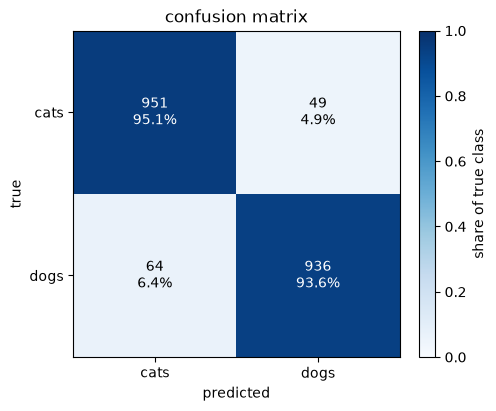

In [7]:
fig = plot_confusion_matrix(report["matrix"], class_names)
plt.show()

In [8]:
targets = pd.DataFrame(check_release_targets(report, PREVIOUS), columns=["rule", "value", "limit", "passed"])
print("RELEASE GATE:", "PASS" if targets["passed"].all() else "FAIL")
targets

RELEASE GATE: PASS


,rule,value,limit,passed
0,cats recall,0.951,0.93,True
1,dogs recall,0.936,0.93,True
2,gap between classes,0.015,0.03,True
3,test set balance (smallest / largest class),1.000,0.90,True
